In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import os
import warnings

warnings.filterwarnings("ignore")

# <모수 검정>

## 1. Two Way ANOVA

- species: 펭귄의 종(Adélie, Gentoo, Chinstrap)
- island: 펭귄이 발견된 섬(Biscoe, Dream, Torgersen)
- bill_length_mm: 부리의 길이(밀리미터)
- bill_depth_mm: 부리의 깊이(밀리미터)
- flipper_length_mm: 날개의 길이(밀리미터)
- body_mass_g: 몸무게(그램)
- sex: 펭귄의 성별

## Q. 펭귄의 종별 펭귄이 발견된 섬별 몸무게 차이 검정

In [4]:
penguins = sns.load_dataset('penguins')
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


In [5]:
penguins.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [6]:
### 결측치가 존재하는 행 제거
penguins = penguins.dropna()
penguins.isnull().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [7]:
print("""
팽귄의 종별, 팽귄이 발견된 섬별 몸무게 차이 검정이므로

2 way ANOVA 검정을 수행한다.

차후에 잔차를 구해 기본 가정인 정규성, 등분산성을 만족하는지 확인한다.
""")


팽귄의 종별, 팽귄이 발견된 섬별 몸무게 차이 검정이므로

2 way ANOVA 검정을 수행한다.

차후에 잔차를 구해 기본 가정인 정규성, 등분산성을 만족하는지 확인한다.



In [8]:
from statsmodels.api import OLS
from statsmodels.stats.anova import anova_lm

formula = "body_mass_g ~ C(species)*C(island)"

model = OLS.from_formula(formula, data=penguins).fit()

result = anova_lm(model, typ=3)

result

,sum_sq,df,F,PR(>F)
Intercept,6.055091e+08,1.0,2834.514116,1.841967e-163
C(species),6.145160e+07,2.0,143.833869,1.414169e-45
C(island),2.063696e+03,2.0,0.004830,9.951814e-01
C(species):C(island),1.224105e+05,4.0,0.143257,7.053089e-01
Residual,7.006738e+07,328.0,NaN,NaN


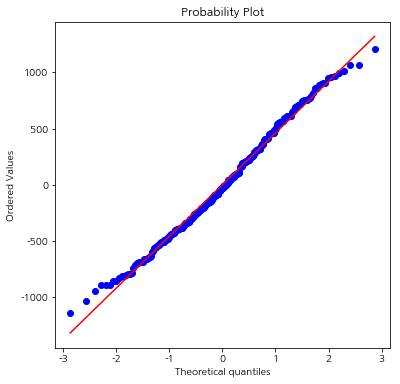

In [9]:
### 잔차의 정규성 검정
from scipy.stats import probplot

residuals = model.resid

plt.figure(figsize=(6,6))

probplot(residuals, dist="norm", plot=plt)

plt.show()

In [10]:
print("""
잔차의 정규성을 만족함을 확인하였다.
""")


잔차의 정규성을 만족함을 확인하였다.



In [11]:
### 잔차의 등분산성 검정
from statsmodels.stats.diagnostic import het_breuschpagan

# H0 : 잔차가 등분산성을 만족한다.
# H1 : 잔차가 등분산성을 만족하지 않는다.

residuals = model.resid

s, p, fstats, f_pvalue = het_breuschpagan(residuals, model.model.exog)

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")
print("유의수준 5% 하에서 귀무가설을 채택한다. 즉, 잔차가 등분산성을 만족한다.")

검정통계량의 p-value : 0.48060773748236996
귀무가설 채택
유의수준 5% 하에서 귀무가설을 채택한다. 즉, 잔차가 등분산성을 만족한다.


In [12]:
print("""
<가설 설정>
<주효과1 검정>
H0 : 종별 몸무게의 평균이 같다.
H1 : 적어도 하나의 종의 몸무게의 평균이 다르다.

<주효과2 검정>
H0 : 발견된 섬별 몸무게의 평균이 같다.
H1 : 적어도 하나의 발견된 섬에서 발견된 몸무게의 평균이 다르다.

<상호작용효과 검정>
H0 : 종과 발견된 섬 간의 상호작용 효과가 없다.
H1 : 종과 발견된 삼 간의 상호작용 효과가 있다.

""")


<가설 설정>
<주효과1 검정>
H0 : 종별 몸무게의 평균이 같다.
H1 : 적어도 하나의 종의 몸무게의 평균이 다르다.

<주효과2 검정>
H0 : 발견된 섬별 몸무게의 평균이 같다.
H1 : 적어도 하나의 발견된 섬에서 발견된 몸무게의 평균이 다르다.

<상호작용효과 검정>
H0 : 종과 발견된 섬 간의 상호작용 효과가 없다.
H1 : 종과 발견된 삼 간의 상호작용 효과가 있다.




In [13]:
result

,sum_sq,df,F,PR(>F)
Intercept,6.055091e+08,1.0,2834.514116,1.841967e-163
C(species),6.145160e+07,2.0,143.833869,1.414169e-45
C(island),2.063696e+03,2.0,0.004830,9.951814e-01
C(species):C(island),1.224105e+05,4.0,0.143257,7.053089e-01
Residual,7.006738e+07,328.0,NaN,NaN


In [14]:
### 주효과1 검정
p = result.loc["C(species)", "PR(>F)"]

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")
print("유의수준 5%하에서 귀무가설을 기각한다. 즉, 적어도 하나의 종의 몸무게의 평균이 다르다.")

검정통계량의 p-value : 1.4141687720379716e-45
귀무가설 기각
유의수준 5%하에서 귀무가설을 기각한다. 즉, 적어도 하나의 종의 몸무게의 평균이 다르다.


In [15]:
### 주효과2 검정
p = result.loc["C(island)", "PR(>F)"]

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")
print("유의수준 5%하에서 귀무가설을 채택한다. 즉, 발견된 섬별 몸무게의 평균이 같다.")

검정통계량의 p-value : 0.9951814215969668
귀무가설 채택
유의수준 5%하에서 귀무가설을 채택한다. 즉, 발견된 섬별 몸무게의 평균이 같다.


In [16]:
### 상호작용효과 검정
p = result.loc["C(species):C(island)", "PR(>F)"]

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")
print("유의수준 5%하에서 귀무가설을 채택한다. 즉, 종과 발견된 섬 간의 상호작용 효과가 없다.")

검정통계량의 p-value : 0.705308922736142
귀무가설 채택
유의수준 5%하에서 귀무가설을 채택한다. 즉, 종과 발견된 섬 간의 상호작용 효과가 없다.


In [17]:
print("""
상호작용효과가 없기 때문에 사후검정을 단순 주효과 분석이 아닌
pairwise_tukeyhsd()로 주효과1인 어느 종간의 몸무게가 다른지에 대한 사후 검정을 실시한다.
""")


상호작용효과가 없기 때문에 사후검정을 단순 주효과 분석이 아닌
pairwise_tukeyhsd()로 주효과1인 어느 종간의 몸무게가 다른지에 대한 사후 검정을 실시한다.



In [18]:
## 사후 검정
from statsmodels.stats.multicomp import pairwise_tukeyhsd

result = pairwise_tukeyhsd(penguins["body_mass_g"], penguins["species"], alpha=0.05)
print(result)

      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
  group1    group2   meandiff p-adj    lower     upper   reject
---------------------------------------------------------------
   Adelie Chinstrap   26.9239 0.9164 -132.3528  186.2005  False
   Adelie    Gentoo 1386.2726   -0.0 1252.2897 1520.2554   True
Chinstrap    Gentoo 1359.3487   -0.0 1194.4304 1524.2671   True
---------------------------------------------------------------


In [19]:
print("""
p-adj > 0.05 ==> 귀무가설 채택 
두 종간 몸무게의 평균이 같다.
p-adj < 0.05 ==> 귀무가설 기각
두 종간 몸무게의 평균이 다르다.

Adelie과 Chinstrap의 종 간의 몸무게 평균은 같으며
Adelie과 Gentoo의 종 간의 몸무게 평균은 다르고
Chinstrap과 Gentoo의 종 간의 몸무게 평균은 다름을 사후검정을 통해 확인할 수 있었다..
""")


p-adj > 0.05 ==> 귀무가설 채택 
두 종간 몸무게의 평균이 같다.
p-adj < 0.05 ==> 귀무가설 기각
두 종간 몸무게의 평균이 다르다.

Adelie과 Chinstrap의 종 간의 몸무게 평균은 같으며
Adelie과 Gentoo의 종 간의 몸무게 평균은 다르고
Chinstrap과 Gentoo의 종 간의 몸무게 평균은 다름을 사후검정을 통해 확인할 수 있었다..



## 2. Multi Way ANOVA

- total_bill : 총 계산 요금 (달러)
- tip : 팁 (달러)
- sex : 성별
- smoker : 흡연 여부
- day : 요일
- time : 식사 시간
- size : 식사 인원

## Q. 성별별 요일별 식사시간별 팁의 평균 검정

In [20]:
### 원본 데이터
tips = sns.load_dataset('tips')
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [21]:
tips.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [22]:
### Multiway ANOVA
from statsmodels.api import OLS
from statsmodels.stats.anova import anova_lm

formula = "tip ~ C(sex)*C(day)*C(time)"
model = OLS.from_formula(formula, data=tips).fit()

result = anova_lm(model, typ=3)

result

,sum_sq,df,F,PR(>F)
Intercept,266.471603,1.0,138.460520,2.143742e-25
C(sex),2.668898,1.0,1.386778,2.401514e-01
C(day),3.727817,3.0,0.645667,5.864028e-01
C(time),0.953247,1.0,0.495314,4.822692e-01
C(sex):C(day),3.947115,3.0,0.683650,5.628434e-01
C(sex):C(time),0.041505,1.0,0.021566,8.833743e-01
C(day):C(time),2.334925,3.0,0.404414,7.499632e-01
C(sex):C(day):C(time),3.349023,3.0,0.580059,6.286464e-01
Residual,448.415792,233.0,NaN,NaN


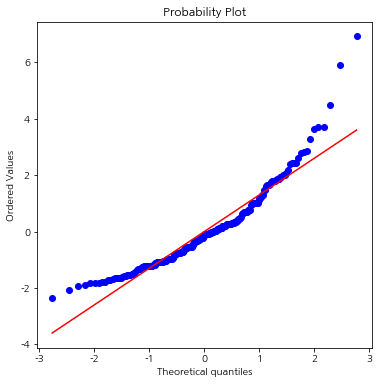

In [23]:
### 잔차 정규성 검정 (Q-Q plot)
from scipy.stats import probplot

residuals = model.resid

plt.figure(figsize=(6,6))

probplot(residuals, dist="norm", plot=plt)

plt.show()

In [24]:
cond = (tips["tip"] <= 0)

tips.loc[cond, :]

,total_bill,tip,sex,smoker,day,time,size


In [25]:
print("""
정규성 만족하지 않으므로 tip 컬럼에 박스콕스 변환을 수행
""")


정규성 만족하지 않으므로 tip 컬럼에 박스콕스 변환을 수행



In [26]:
### 종속변수 box-cox 변환 수행
from sklearn.preprocessing import PowerTransformer

ptb = PowerTransformer(method="box-cox")
tips[["tip_boxcox"]] = ptb.fit_transform(tips[["tip"]])
tips

,total_bill,tip,sex,smoker,day,time,size,tip_boxcox
0,16.99,1.01,Female,No,Sun,Dinner,2,-2.340991
1,10.34,1.66,Male,No,Sun,Dinner,3,-1.143771
2,21.01,3.50,Male,No,Sun,Dinner,3,0.584417
3,23.68,3.31,Male,No,Sun,Dinner,2,0.457911
4,24.59,3.61,Female,No,Sun,Dinner,4,0.654363
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,1.754000
240,27.18,2.00,Female,Yes,Sat,Dinner,2,-0.704416
241,22.67,2.00,Male,Yes,Sat,Dinner,2,-0.704416
242,17.82,1.75,Male,No,Sat,Dinner,2,-1.018749


In [27]:
### Multiway ANOVA 다시 적합
from statsmodels.api import OLS
from statsmodels.stats.anova import anova_lm

formula = "tip_boxcox ~ C(sex)*C(day)*C(time)"
model = OLS.from_formula(formula, data=tips).fit()

result = anova_lm(model, typ=3)

result

,sum_sq,df,F,PR(>F)
Intercept,0.000165,1.0,0.000165,0.989750
C(sex),1.675320,1.0,1.674747,0.196905
C(day),3.533389,3.0,1.177393,0.319058
C(time),1.007998,1.0,1.007653,0.316507
C(sex):C(day),2.603853,3.0,0.867654,0.458530
C(sex):C(time),0.000223,1.0,0.000223,0.988094
C(day):C(time),2.869431,3.0,0.956149,0.414197
C(sex):C(day):C(time),2.361666,3.0,0.786952,0.502254
Residual,233.079805,233.0,NaN,NaN


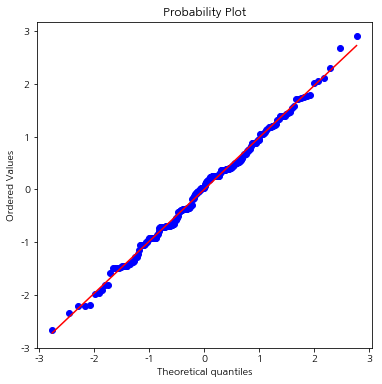

In [28]:
### 잔차 정규성 검정 (Q-Q plot)
from scipy.stats import probplot

residuals = model.resid

plt.figure(figsize=(6,6))

probplot(residuals, dist="norm", plot=plt)

plt.show()

In [29]:
### 등분산성 검정
from statsmodels.stats.diagnostic import het_breuschpagan

# H0 : 잔차가 등분산성을 만족한다.
# H1 : 잔차가 등분산성을 만족하지 않는다.

residuals = model.resid

s, p, fstats, f_pvalue = het_breuschpagan(residuals, model.model.exog)

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")

검정통계량의 p-value : 0.9433995628646473
귀무가설 채택


In [30]:
print("""
등분산 가정을 만족함을 확인할 수 있었다.
""")


등분산 가정을 만족함을 확인할 수 있었다.



In [31]:
result

,sum_sq,df,F,PR(>F)
Intercept,0.000165,1.0,0.000165,0.989750
C(sex),1.675320,1.0,1.674747,0.196905
C(day),3.533389,3.0,1.177393,0.319058
C(time),1.007998,1.0,1.007653,0.316507
C(sex):C(day),2.603853,3.0,0.867654,0.458530
C(sex):C(time),0.000223,1.0,0.000223,0.988094
C(day):C(time),2.869431,3.0,0.956149,0.414197
C(sex):C(day):C(time),2.361666,3.0,0.786952,0.502254
Residual,233.079805,233.0,NaN,NaN


In [32]:
print("""
[가설 설정]
<주효과1 검정>
H0 : 성별별 팁의 평균이 같다.
H1 : 성별별 팁의 평균이 다르다.

<주효과2 검정>
H0 : 요일별 팁의 평균이 같다.
H1 : 요일별 팁의 평균이 다르다.

<주효과3 검정>
H0 : 식사시간별 팁의 평균이 같다.
H1 : 식사시간별 팁의 평균이 다르다.

<상호작용효과1 검정>
H0 : 성별과 요일 간의 상호작용 효과가 없다.
H1 : 성별과 요일 간의 상호작용 효과가 있다.

<상호작용효과2 검정>
H0 : 성별과 식사시간 간의 상호작용 효과가 없다.
H1 : 성별과 식사시간 간의 상호작용 효과가 있다.

<상호작용효과3 검정>
H0 : 요일과 식사시간 간의 상호작용 효과가 없다.
H1 : 요일과 식사시간 간의 상호작용 효과가 있다.

<상호작용효과4 검정>
H0 : 성별, 요일, 식사시간 간 3원 상호작용 효과가 없다.
H1 : 성별, 요일, 식사시간 간 3원 상호작용 효과가 있다.
""")


[가설 설정]
<주효과1 검정>
H0 : 성별별 팁의 평균이 같다.
H1 : 성별별 팁의 평균이 다르다.

<주효과2 검정>
H0 : 요일별 팁의 평균이 같다.
H1 : 요일별 팁의 평균이 다르다.

<주효과3 검정>
H0 : 식사시간별 팁의 평균이 같다.
H1 : 식사시간별 팁의 평균이 다르다.

<상호작용효과1 검정>
H0 : 성별과 요일 간의 상호작용 효과가 없다.
H1 : 성별과 요일 간의 상호작용 효과가 있다.

<상호작용효과2 검정>
H0 : 성별과 식사시간 간의 상호작용 효과가 없다.
H1 : 성별과 식사시간 간의 상호작용 효과가 있다.

<상호작용효과3 검정>
H0 : 요일과 식사시간 간의 상호작용 효과가 없다.
H1 : 요일과 식사시간 간의 상호작용 효과가 있다.

<상호작용효과4 검정>
H0 : 성별, 요일, 식사시간 간 3원 상호작용 효과가 없다.
H1 : 성별, 요일, 식사시간 간 3원 상호작용 효과가 있다.



In [33]:
result

,sum_sq,df,F,PR(>F)
Intercept,0.000165,1.0,0.000165,0.989750
C(sex),1.675320,1.0,1.674747,0.196905
C(day),3.533389,3.0,1.177393,0.319058
C(time),1.007998,1.0,1.007653,0.316507
C(sex):C(day),2.603853,3.0,0.867654,0.458530
C(sex):C(time),0.000223,1.0,0.000223,0.988094
C(day):C(time),2.869431,3.0,0.956149,0.414197
C(sex):C(day):C(time),2.361666,3.0,0.786952,0.502254
Residual,233.079805,233.0,NaN,NaN


In [34]:
### 주효과1 검정
p = result.loc["C(sex)", "PR(>F)"]

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")
print("유의수준 5%하에서 귀무가설을 채택한다. 즉, 성별별 팁의 평균이 같다.")

검정통계량의 p-value : 0.19690516000883027
귀무가설 채택
유의수준 5%하에서 귀무가설을 채택한다. 즉, 성별별 팁의 평균이 같다.


In [35]:
### 주효과2 검정
p = result.loc["C(day)", "PR(>F)"]

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")
print("유의수준 5%하에서 귀무가설을 채택한다. 즉, 요일별 팁의 평균이 같다.")

검정통계량의 p-value : 0.3190575012152118
귀무가설 채택
유의수준 5%하에서 귀무가설을 채택한다. 즉, 요일별 팁의 평균이 같다.


In [36]:
### 주효과3 검정
p = result.loc["C(time)", "PR(>F)"]

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")
print("유의수준 5%하에서 귀무가설을 채택한다. 즉, 식사시간별 팁의 평균이 같다.")

검정통계량의 p-value : 0.31650706988489047
귀무가설 채택
유의수준 5%하에서 귀무가설을 채택한다. 즉, 식사시간별 팁의 평균이 같다.


In [37]:
### 상호작용효과1 검정
p = result.loc["C(sex):C(day)", "PR(>F)"]

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")
print("유의수준 5%하에서 귀무가설을 채택한다. 즉, 성별과 요일 간의 상호작용 효과가 없다.")

검정통계량의 p-value : 0.45853028502754434
귀무가설 채택
유의수준 5%하에서 귀무가설을 채택한다. 즉, 성별과 요일 간의 상호작용 효과가 없다.


In [38]:
### 상호작용효과2 검정
p = result.loc["C(sex):C(time)", "PR(>F)"]

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")
print("유의수준 5%하에서 귀무가설을 채택한다. 즉, 성별과 식사시간 간의 상호작용 효과가 없다.")

검정통계량의 p-value : 0.9880940028370296
귀무가설 채택
유의수준 5%하에서 귀무가설을 채택한다. 즉, 성별과 식사시간 간의 상호작용 효과가 없다.


In [39]:
### 상호작용효과3 검정
p = result.loc["C(day):C(time)", "PR(>F)"]

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")
print("유의수준 5%하에서 귀무가설을 채택한다. 즉, 요일과 식사시간 간의 상호작용 효과가 없다.")

검정통계량의 p-value : 0.41419664122726696
귀무가설 채택
유의수준 5%하에서 귀무가설을 채택한다. 즉, 요일과 식사시간 간의 상호작용 효과가 없다.


In [40]:
### 상호작용효과4 검정
p = result.loc["C(sex):C(day):C(time)", "PR(>F)"]

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")
print("유의수준 5%하에서 귀무가설을 채택한다. 즉, 성별, 요일, 식사시간 간 3원 상호작용 효과가 없다.")

검정통계량의 p-value : 0.5022541011681994
귀무가설 채택
유의수준 5%하에서 귀무가설을 채택한다. 즉, 성별, 요일, 식사시간 간 3원 상호작용 효과가 없다.


In [41]:
print("""
주효과 검정 3가지 모두 귀무가설 채택이므로 평균이 동일한 것임을 확인하였기에 사후검정을 하지 않는다.

그리고 상호작용효과 모두 상호작용효과가 없는것이 확인되었다.
""")


주효과 검정 3가지 모두 귀무가설 채택이므로 평균이 동일한 것임을 확인하였기에 사후검정을 하지 않는다.

그리고 상호작용효과 모두 상호작용효과가 없는것이 확인되었다.



# <비모수 검정>

## Kruskal Wallis Test (크루스칼 왈리스 검정)

## <문제1>

<mpg 데이터>

1) mpg: 연비

2) cylinders: 실린더 개수

3) displacement: 배기량

4) horsepower: 마력

5) weight: 무게

6) acceleration: 엔진이 초당 얻을 수 있는 가속력

7) model year: 출시 년도

8) origin: 제조 장소(1: 미국 USA, 2: 유럽 EU, 3: 일본 JPN)

9) car name: 자동차 이름

## Q. 제조 국가(origin)별 연비(mpg) 평균 검정

In [42]:
### 원본 데이터

mpg = sns.load_dataset("mpg")
mpg

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


In [43]:
mpg.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [44]:
### One way ANOVA 검정
from statsmodels.api import OLS
from statsmodels.stats.anova import anova_lm

formula = "mpg ~ C(origin)"
model = OLS.from_formula(formula, data=mpg).fit()

result = anova_lm(model)
result

,df,sum_sq,mean_sq,F,PR(>F)
C(origin),2.0,8072.820662,4036.410331,98.541795,1.915486e-35
Residual,395.0,16179.754815,40.961405,NaN,NaN


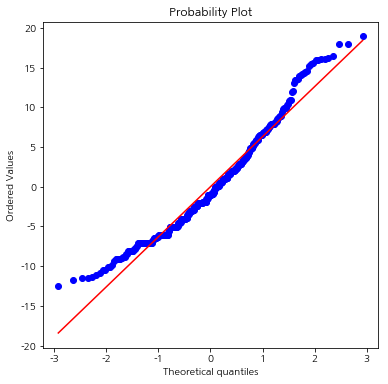

In [45]:
### 기본 가정 확인 (정규성 검정)
from scipy.stats import probplot

residuals = model.resid

plt.figure(figsize=(6,6))

probplot(residuals, dist="norm", plot=plt)

plt.show()

In [46]:
from scipy.stats import shapiro

# H0 : 잔차가 정규성을 만족한다.
# H1 : 잔차가 정규성을 만족하지 않는다.

residuals = model.resid

s, p = shapiro(residuals)

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")
print("유의수준 5% 하에서 귀무가설을 기각한다. 즉, 잔차가 정규성을 만족하지 않는다.")

검정통계량의 p-value : 2.4660568698209318e-08
귀무가설 기각
유의수준 5% 하에서 귀무가설을 기각한다. 즉, 잔차가 정규성을 만족하지 않는다.


In [47]:
print("""
정규성을 만족하지 않으므로 비모수 검정인 kruskal Wallis 검정을 수행한다.
""")


정규성을 만족하지 않으므로 비모수 검정인 kruskal Wallis 검정을 수행한다.



In [48]:
mpg["origin"].value_counts()

usa       249
japan      79
europe     70
Name: origin, dtype: int64

In [49]:
### 그룹 나누기
cond = (mpg["origin"] == "usa")
cond1 = (mpg["origin"] == "japan")
cond2 = (mpg["origin"] == "europe")

gUSA = mpg.loc[cond, "mpg"].to_numpy()
gJapan = mpg.loc[cond1, "mpg"].to_numpy()
gEurope = mpg.loc[cond2, "mpg"].to_numpy()

In [50]:
### Kruskal Wallis 검정 수행
from scipy.stats import kruskal

# H0 : 제조장소별 연비의 중앙값이 같다.
# H1 : 적어도 한 제조장소의 연비의 중앙값이 다르다.

s, p = kruskal(gUSA, gJapan, gEurope)

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")

검정통계량의 p-value : 6.354882752621894e-30
귀무가설 기각


In [51]:
print("""
귀무가설을 기각하므로 어느 제조장소간 연비의 중앙값이 다른지 알아보기 위해
사후검정을 수행한다.
kruskal Wallis 검정의 사후검정으로 Dunn's test로 사후검정 수행
""")


귀무가설을 기각하므로 어느 제조장소간 연비의 중앙값이 다른지 알아보기 위해
사후검정을 수행한다.
kruskal Wallis 검정의 사후검정으로 Dunn's test로 사후검정 수행



In [52]:
### Dunn's Test 사후검정 (변수간 p-value를 보여준다.)
import scikit_posthocs as sp

# H0 : 두 제조 장소간 연비의 중앙값은 같다.
# H1 : 두 제조 장소간 연비의 중앙값은 다르다.

result = sp.posthoc_dunn(mpg,                   ### 원본데이터
                         val_col="mpg",         # 종속변수 컬럼명
                         group_col="origin",    # 독립변수 컬럼명
                         p_adjust="bonferroni" 
                         )
result.round(5)

,europe,japan,usa
europe,1.00000,0.16655,0.0
japan,0.16655,1.00000,0.0
usa,0.00000,0.00000,1.0


In [53]:
print("""
유럽과 일본의 연비의 중앙값은 같다.
그리고 유럽과 미국의 연비의 중앙값은 다르며
일본과 미국의 연비의 중앙값이 다름을 사후검정을 통해 확인할 수 있다.
""")


유럽과 일본의 연비의 중앙값은 같다.
그리고 유럽과 미국의 연비의 중앙값은 다르며
일본과 미국의 연비의 중앙값이 다름을 사후검정을 통해 확인할 수 있다.



## <문제2>

### Q. 그룹별 점수 차이를 검정하시오.

In [85]:
print("""
모수와 비모수 선택하는 기준이 뭔지 모르겠다...
""")


모수와 비모수 선택하는 기준이 뭔지 모르겠다...



In [84]:
file_path = "./data/kruskal.csv"
df = pd.read_csv(file_path)
df

,학생ID,그룹,점수
0,1,전통학습,67
1,2,전통학습,72
2,3,전통학습,70
3,4,전통학습,66
4,5,전통학습,74
5,6,온라인학습,80
6,7,온라인학습,85
7,8,온라인학습,78
8,9,온라인학습,82
9,10,온라인학습,81


In [79]:
### One way ANOVA
from statsmodels.api import OLS
from statsmodels.stats.anova import anova_lm

formula = "점수 ~ C(그룹)"
model = OLS.from_formula(formula, data=df).fit()

result = anova_lm(model)
result

,df,sum_sq,mean_sq,F,PR(>F)
C(그룹),2.0,336.933333,168.466667,22.765766,0.000082
Residual,12.0,88.800000,7.400000,NaN,NaN


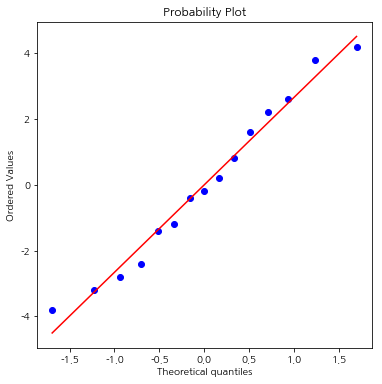

In [80]:
### 정규성 검정 (Q-Q plot)
from scipy.stats import probplot

residuals = model.resid

plt.figure(figsize=(6,6))

probplot(residuals, dist="norm", plot=plt)

plt.show()

In [82]:
### shapiro 검정
from scipy.stats import shapiro

residuals = model.resid

s, p = shapiro(residuals)

p

0.7667443156242371

In [55]:
df["그룹"].value_counts()

온라인학습    5
혼합학습     5
전통학습     5
Name: 그룹, dtype: int64

In [56]:
cond = (df["그룹"] == "온라인학습")
cond1 = (df["그룹"] == "혼합학습")
cond2 = (df["그룹"] == "전통학습")

In [60]:
## 그룹 나누기
gOnline = df.loc[cond, "점수"].copy()
gMix = df.loc[cond1, "점수"].copy()
gTrad = df.loc[cond2, "점수"].copy()

In [62]:
### 정규성 검정
from scipy.stats import shapiro

s, p = shapiro(gOnline)

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")

검정통계량의 p-value : 0.9546433091163635
귀무가설 채택


In [63]:
### 정규성 검정
from scipy.stats import shapiro

s, p = shapiro(gMix)

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")

검정통계량의 p-value : 0.7539715766906738
귀무가설 채택


In [64]:
### 정규성 검정
from scipy.stats import shapiro

s, p = shapiro(gTrad)

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")

검정통계량의 p-value : 0.7374202013015747
귀무가설 채택


In [66]:
### 등분산 검정
from scipy.stats import levene

levene(gOnline, gMix, gTrad)

LeveneResult(statistic=0.6176470588235293, pvalue=0.5555023440711991)

In [67]:
print("""
정규성, 등분산성 검정 모두 만족
""")


정규성, 등분산성 검정 모두 만족



In [69]:
### kruskal Wallis 검정
from scipy.stats import kruskal

# H0 : 학습방법별 점수의 중앙값이 같다.
# H1 : 적어도 하나의 학습방법의 점수 중앙값이 다르다.

s, p = kruskal(gOnline, gMix, gTrad)

p

0.0033537558275474294

In [74]:
### 사후검정
import scikit_posthocs as sp

# H0 : 두 학습방법의 점수 중앙값이 같다.
# H1 : 두 학습방법의 점수 중앙값이 다르다.

result = sp.posthoc_dunn(df,                    ## 원본 데이터
                         val_col="점수",        #  종속변수 컬럼명
                         group_col="그룹",      #  독립변수 컬럼명
                         p_adjust="bonferroni"  #  본페로니 보정
                         )
result

,온라인학습,전통학습,혼합학습
온라인학습,1.000000,0.002323,0.470785
전통학습,0.002323,1.000000,0.154863
혼합학습,0.470785,0.154863,1.000000


In [75]:
print("""
전통학습과 온라인 학습의 점수 중앙값은 다르다.
그리고 혼합학습과 온라인 학습의 점수 중앙값은 같으며
혼합학습과 전통학습의 점수 중앙값은 같다.
""")


전통학습과 온라인 학습의 점수 중앙값은 다르다.
그리고 혼합학습과 온라인 학습의 점수 중앙값은 같으며
혼합학습과 전통학습의 점수 중앙값은 같다.



## FriedMann Test (프리드먼 검정)

연구자는 새로운 혈압 치료제의 효과를 비교하기 위해 12명의 환자를 대상으로 실험을 진행하였다.
각 환자는 치료A, 치료B, 치료C를 모두 경험했으며, 치료 직후 측정한 **수축기 혈압(단위: mmHg)**이 아래와 같이 기록되었다.

1. 이 연구의 **연구가설(귀무가설, 대립가설)**을 설정하시오.

2. 가설 검정을 수행하시오.

3. 검정 결과를 해석하고, 어떤 결론을 내릴 수 있는지 설명하시오.

4. 만약 유의미한 차이가 있다면, 사후검정(예: Wilcoxon 부호순위검정)을 어떻게 적용할 수 있을지 설명하시오.

In [102]:
file_path = "./data/friedman.csv"

df = pd.read_csv(file_path)
df

,환자ID,치료A,치료B,치료C
0,1,135,128,120
1,2,142,130,118
2,3,138,132,122
3,4,145,127,119
4,5,140,129,121
5,6,137,131,117
6,7,139,126,123
7,8,141,133,124
8,9,143,134,120
9,10,136,128,122


In [103]:
### 원본 데이터
df

,환자ID,치료A,치료B,치료C
0,1,135,128,120
1,2,142,130,118
2,3,138,132,122
3,4,145,127,119
4,5,140,129,121
5,6,137,131,117
6,7,139,126,123
7,8,141,133,124
8,9,143,134,120
9,10,136,128,122


In [104]:
### 그룹나누기
gA = df["치료A"].to_numpy()
gB = df["치료B"].to_numpy()
gC = df["치료C"].to_numpy()

In [105]:
### 정규성 검정
from scipy.stats import shapiro

s, p = shapiro(gA)

print(f"검정통계량의 p-value : {p}")

검정통계량의 p-value : 0.8795967698097229


In [106]:
### 정규성 검정
from scipy.stats import shapiro

s, p = shapiro(gB)

print(f"검정통계량의 p-value : {p}")

검정통계량의 p-value : 0.7445921897888184


In [107]:
### 정규성 검정
from scipy.stats import shapiro

s, p = shapiro(gC)

print(f"검정통계량의 p-value : {p}")

검정통계량의 p-value : 0.8295503854751587


In [108]:
### 프리드먼 검정
from scipy.stats import friedmanchisquare

# H0 : 치료제별 수축기 혈압의 평균 순위는 같다.
# H1 : 적어도 하나의 치료제의 수축기 혈압의 평균 순위는 다르다.

s, p = friedmanchisquare(gA, gB, gC)

print(f"검정통계량 : {s}")
print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")

검정통계량 : 24.0
검정통계량의 p-value : 6.144212353328207e-06
귀무가설 기각


In [101]:
### wide 데이터면 그대로
### long 데이터면 컬럼 지정

In [131]:
### Nemenyi Test 사후 검정(Wide 데이터일 때)

result = sp.posthoc_nemenyi_friedman(df[["치료A", "치료B", "치료C"]])

result

,치료A,치료B,치료C
치료A,1.000000,0.038045,0.001000
치료B,0.038045,1.000000,0.038045
치료C,0.001000,0.038045,1.000000


In [132]:
df_melt = pd.melt(df,
                 id_vars="환자ID",
                 value_vars=["치료A","치료B","치료C"],
                 var_name="치료제종류",
                 value_name="수축기혈압"
                 )
df_melt

,환자ID,치료제종류,수축기혈압
0,1,치료A,135
1,2,치료A,142
2,3,치료A,138
3,4,치료A,145
4,5,치료A,140
5,6,치료A,137
6,7,치료A,139
7,8,치료A,141
8,9,치료A,143
9,10,치료A,136


In [135]:
### Nemenyi Test 사후 검정 (long 데이터 일때)
import scikit_posthocs as sp

result = sp.posthoc_nemenyi_friedman(df_melt,                    ## 원본 데이터(Long 데이터)
                                     y_col="수축기혈압",         #  종속변수 컬럼명
                                     group_col="치료제종류",     #  독립변수 컬럼명
                                     block_col="환자ID",         #  고유식별자 컬럼명
                                     melted=True                 #  Long 데이터일때 필수 True
                                     )
result

,치료A,치료B,치료C
치료A,1.000000,0.038045,0.001000
치료B,0.038045,1.000000,0.038045
치료C,0.001000,0.038045,1.000000


In [136]:
print("""
<가설 설정>
H0 : 두 치료제의 수축기 혈압의 평균 순위가 같다.
H1 : 두 치료제의 수축기 혈압의 평균 순위가 다르다.
""")


<가설 설정>
H0 : 두 치료제의 수축기 혈압의 평균 순위가 같다.
H1 : 두 치료제의 수축기 혈압의 평균 순위가 다르다.

